# Cardiopatia

> Data: **2025-10-31**
>
> Autore: **Luigi Malaguti**

##

---

## Parte 0: Il Dataset

Il dataset si trova al [link](https://bit.ly/3CLdwU7) (preso da [Kaggle](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction)) e contiene dati relativi ad alcuni
pazienti:

- **Age**: età del paziente [anni]
- **Sex**: sesso del paziente [M: maschio, F: femmina]
- **ChestPainType**: tipo di dolore toracico [TA: Angina tipica, ATA: Angina atipica, NAP: Dolore non
anginoso, ASY: Asintomatico]
- **RestingBP**: pressione sanguigna a riposo [mm Hg]
- **Cholesterol**: colesterolo sierico [mm/dl]
- **FastingBS**: zucchero nel sangue a digiuno [1: se FastingBS > 120 mg/dl, 0: altrimenti]
- **RestingECG**: elettrocardiogramma a riposo [Normale, ST: anomalia dell'onda T-ST, LVH: ipertrofia
ventricolare sinistra]
- **MaxHR**: frequenza cardiaca massima raggiunta [valore numerico tra 60 e 202]
- **ExerciseAngina**: angina indotta da esercizio [SÌ, NO]
- **Oldpeak**: valore numerico misurato in depressione
- **ST_Slope**: pendenza del picco [Up: in salita, Flat: piatto, Down: in discesa]
- **HeartDisease**: classe da predire [1: cardiopatia, 0: normale]

### Imports

In [ ]:
!curl -sLo dataset.zip "https://www.kaggle.com/api/v1/datasets/download/fedesoriano/heart-failure-prediction"
!unzip -o dataset.zip
!mv heart.csv dataset.csv
# FILE_ID = "file_id"
# !curl -sLo dataset.csv "https://drive.google.com/uc?export=download&id={FILE_ID}"

Archive:  dataset.zip
  inflating: heart.csv               


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV

### Dataset

In [ ]:
df = pd.read_csv("dataset.csv")

#### Overview

In [ ]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


#### Instances

In [ ]:
df.shape

(918, 12)

#### Missing values

In [ ]:
df.isnull().sum().sum()

np.int64(0)

#### Balancing

In [ ]:
df["HeartDisease"].value_counts()

,count
HeartDisease,
1,508
0,410


<Axes: >

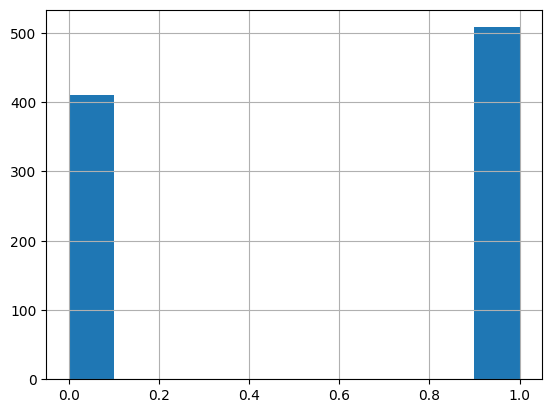

In [ ]:
df["HeartDisease"].hist()

##

---

## Parte 2: Trasformazione e Predizione

### Domanda 01

A partire dal dataset originale, eliminare eventuali attributi inutili (giustificare la scelta), eliminare eventuali istanze che contengono valori nulli, trasformare opportunamente valori categorici e dividere il dataset in modo che 3/4 degli elementi siano contenuti in un nuovo dataset "**train**" e 1/4 nel dataset "**test**" preservando le proporzioni delle classi nel target.

In [ ]:
df.dropna(inplace=True)

> Rimuovo le istanze che contengono dei valori nulli, che in questo dataset non sono presenti.
>
> Non c'è bisogno di rimuovere nessun attributo inutile, in quanto tutti gli attributi presenti nel dataset sono rilevanti al fine della predizione.

In [ ]:
categorical_columns = df.select_dtypes(include="object")
categorical_columns

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up
...,...,...,...,...,...
913,M,TA,Normal,N,Flat
914,M,ASY,Normal,N,Flat
915,M,ASY,Normal,Y,Flat
916,F,ATA,LVH,N,Flat


In [ ]:
encoder = LabelEncoder()
columns = categorical_columns.columns
df[columns] = df[columns].apply(encoder.fit_transform)
df[columns]

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,1,1,1,0,2
1,0,2,1,0,1
2,1,1,2,0,2
3,0,0,1,1,1
4,1,2,1,0,2
...,...,...,...,...,...
913,1,3,1,0,1
914,1,0,1,0,1
915,1,0,1,1,1
916,0,1,0,0,1


In [ ]:
X, y = df.drop("HeartDisease", axis=1), df["HeartDisease"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, random_state=123, stratify=y)

---

### Domanda 02

Utilizzando il dataset train, allenare il modello **DecisionTree** e valutare l'accuratezza ottenuta sia sul dataset train sia sul dataset test. Confrontare i risultati ottenuti con quelli ottenuti con una predizione basata sul modello **KNeighborsClassifier** e con la predizione effettuata da un dummy classifier a scelta.

In [ ]:
models = {
    "DecisionTree": DecisionTreeClassifier(random_state=123),
    "KNeighbors": KNeighborsClassifier(),
    "Dummy": DummyClassifier(random_state=123),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    print(name)
    print("=" * 30)
    print("Train")
    print("    Accuracy:", accuracy_score(y_train, y_pred_train))
    print("    F1:", f1_score(y_train, y_pred_train))
    print(confusion_matrix(y_train, y_pred_train))
    print("-" * 30)
    print("Test")
    print("    Accuracy:", accuracy_score(y_test, y_pred_test))
    print("    F1:", f1_score(y_test, y_pred_test))
    print(confusion_matrix(y_test, y_pred_test))
    print("=" * 30)
    print()

DecisionTree
Train
    Accuracy: 1.0
    F1: 1.0
[[307   0]
 [  0 381]]
------------------------------
Test
    Accuracy: 0.808695652173913
    F1: 0.8211382113821138
[[ 85  18]
 [ 26 101]]

KNeighbors
Train
    Accuracy: 0.7703488372093024
    F1: 0.7953367875647669
[[223  84]
 [ 74 307]]
------------------------------
Test
    Accuracy: 0.7434782608695653
    F1: 0.7756653992395437
[[ 69  34]
 [ 25 102]]

Dummy
Train
    Accuracy: 0.5537790697674418
    F1: 0.7128157156220767
[[  0 307]
 [  0 381]]
------------------------------
Test
    Accuracy: 0.5521739130434783
    F1: 0.711484593837535
[[  0 103]
 [  0 127]]



> Il modello `DecisionTree` ha una performance perfette sul modello di train, essendo un albero decisionale e in quanto addestrato sui dati predetti. Nel dataset di train le performance calano un pò, essendo dati nuovi. Ad ogni modo, ha delle buone performance, con la metrica F1 maggiore rispetto l'accuratezza.
>
> Discorso simile per quanto riguarda il modello `KNeighbors`, con la sola differenza che ha performance leggermente inferiori rispetto al modello `DecisionTree`
>
> Il modello `Dummy` è essenzialmente un modello che effettua predizioni casuali, in questo caso secondo la classe maggoritaria, quindi avrà necessariamente performance scadenti.

---

### Domanda 03

Confrontare l’accuratezza ottenuta nel punto precedente con l’accuratezza che si ottiene con una **10 Fold cross validation**.

In [ ]:
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=10)
    print(name)
    print("=" * 30)
    print("    Accuracy:", scores.mean())
    print("-" * 30)
    print(scores)
    print("=" * 30)
    print()

DecisionTree
    Accuracy: 0.7863354037267081
------------------------------
[0.79347826 0.84782609 0.80434783 0.81521739 0.82608696 0.77173913
 0.80434783 0.77173913 0.7032967  0.72527473]

KNeighbors
    Accuracy: 0.7035236502627807
------------------------------
[0.65217391 0.69565217 0.85869565 0.80434783 0.72826087 0.60869565
 0.7826087  0.66304348 0.61538462 0.62637363]

Dummy
    Accuracy: 0.553368370759675
------------------------------
[0.55434783 0.55434783 0.55434783 0.55434783 0.55434783 0.55434783
 0.55434783 0.55434783 0.54945055 0.54945055]



> Anche attraverso la 10 fold cross validation, le performance rimangono in linea con quelle viste precedentemente. Il `DecisionTree` risulta essere più accurato rispetto ai restanti modelli.

---

### Domanda 04

Scalare i valori di *RestingBP*, *Cholesterol* e *MaxHR* in un intervallo tra 0 e 1 utilizzando la funzione **MinMaxScaler**.

In [ ]:
scaler = MinMaxScaler()
columns = ["RestingBP", "Cholesterol", "MaxHR"]
df[columns] = scaler.fit_transform(df[columns])
df[columns]

,RestingBP,Cholesterol,MaxHR
0,0.70,0.479270,0.788732
1,0.80,0.298507,0.676056
2,0.65,0.469320,0.267606
3,0.69,0.354892,0.338028
4,0.75,0.323383,0.436620
...,...,...,...
913,0.55,0.437811,0.507042
914,0.72,0.320066,0.570423
915,0.65,0.217247,0.387324
916,0.65,0.391376,0.802817


---

### Domanda 05

Analizzare la **correlazione tra le feature** del dataset, creare un dataframe che contiene, oltre alla colonna target, le 5 feature più correlate (positivamente) al target. La predizione effettuata con DecisionTree migliora?

In [ ]:
correlation_matrix = df.corr()
correlation_matrix

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
Age,1.000000,0.055750,-0.077150,0.254399,-0.095282,0.198039,-0.007484,-0.382045,0.215793,0.258612,-0.268264,0.282039
Sex,0.055750,1.000000,-0.126559,0.005133,-0.200092,0.120076,0.071552,-0.189186,0.190664,0.105734,-0.150693,0.305445
ChestPainType,-0.077150,-0.126559,1.000000,-0.020647,0.067880,-0.073151,-0.072537,0.289123,-0.354727,-0.177377,0.213521,-0.386828
RestingBP,0.254399,0.005133,-0.020647,1.000000,0.100893,0.070193,0.022656,-0.112135,0.155101,0.164803,-0.075162,0.107589
Cholesterol,-0.095282,-0.200092,0.067880,0.100893,1.000000,-0.260974,-0.196544,0.235792,-0.034166,0.050148,0.111471,-0.232741
FastingBS,0.198039,0.120076,-0.073151,0.070193,-0.260974,1.000000,0.087050,-0.131438,0.060451,0.052698,-0.175774,0.267291
RestingECG,-0.007484,0.071552,-0.072537,0.022656,-0.196544,0.087050,1.000000,-0.179276,0.077500,-0.020438,-0.006778,0.057384
MaxHR,-0.382045,-0.189186,0.289123,-0.112135,0.235792,-0.131438,-0.179276,1.000000,-0.370425,-0.160691,0.343419,-0.400421
ExerciseAngina,0.215793,0.190664,-0.354727,0.155101,-0.034166,0.060451,0.077500,-0.370425,1.000000,0.408752,-0.428706,0.494282
Oldpeak,0.258612,0.105734,-0.177377,0.164803,0.050148,0.052698,-0.020438,-0.160691,0.408752,1.000000,-0.501921,0.403951


In [ ]:
top_correlated_features = correlation_matrix["HeartDisease"].sort_values(ascending=False)[:6]
top_correlated_features

,HeartDisease
HeartDisease,1.000000
ExerciseAngina,0.494282
Oldpeak,0.403951
Sex,0.305445
Age,0.282039
FastingBS,0.267291


In [ ]:
df_correlated = df[top_correlated_features.index]
X, y = df_correlated.drop("HeartDisease", axis=1), df_correlated["HeartDisease"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, random_state=123, stratify=y)

In [ ]:
decision_tree = models["DecisionTree"]
decision_tree.fit(X_train, y_train)
y_pred = decision_tree.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.691304347826087
F1: 0.7078189300411523
[[73 30]
 [41 86]]


> No, le performance del modello `DecisionTree` non migliorano rispetto ai precedenti test.

---

### Domanda 06

A partire dal dataset iniziale (in cui sono stati eliminati eventuali attributi inutili ed eventuali istanze con valori nulli e sono stati opportunamente trasformati i valori categorici) trovare i **valori migliori dei parametri** *criterion* e *max_depth* del classificatore DecisionTree. Come varia l’accuratezza della predizione?

In [ ]:
df = pd.read_csv("dataset.csv")
df.dropna(inplace=True)
columns = df.select_dtypes(include="object").columns
df[columns] = df[columns].apply(encoder.fit_transform)
X, y = df.drop("HeartDisease", axis=1), df["HeartDisease"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, random_state=123, stratify=y)

In [ ]:
decision_tree = models["DecisionTree"]

params = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [None, 5, 10, 15, 20],
}
grid_search = GridSearchCV(decision_tree, params, cv=10)
grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Best parameters: {'criterion': 'gini', 'max_depth': 5}
Best score: 0.8343563512361467
Accuracy: 0.8173913043478261
F1: 0.8278688524590164
[[ 87  16]
 [ 26 101]]


> Le performance del modello `DecisionTree`, dopo aver ottenuto i parametri migliori per `criterion` e `max_depth`, migliorano di qualche punto percentuale. Il miglioramento c'è, anche se davvero minimo.